In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

In [11]:
nzx_tickers = [
    "FPH.NZ",  # Fisher & Paykel Healthcare
    "FSF.NZ",  # Fonterra Shareholders Fund
    "FCG.NZ",  # Fonterra co-op group
    "SEK.NZ",  # Seeka Ltd (Kiwifruit exporter)
    "LIC.NZ",  # Livestock Improvement Corporation
    "TWR.NZ",  # Tower
    "AIR.NZ",  # Air New Zealand
    "SPK.NZ",  # Spark
    "AIA.NZ",  # Auckland Airport
    "MEL.NZ",  # Meridian Energy
    "MCY.NZ",  # Mercury Energy
    "CEN.NZ",  # Contact Energy
    "GNE.NZ",  # Genesis Energy
    "CNU.NZ",  # Chorus
]


In [3]:
# Plot Stock Prices

def plot_stock_prices(tickers, start_date, end_date):
    """
    Fetches stock price data for specified tickers over a date range and plots the prices.

    Parameters:
        tickers (list of str): Stock tickers to retrieve data for.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
    """
    # for ticker in tickers:
    #    print(f"Currency : {yf.Ticker(ticker).info['currency']}")


    # Fetch historical data for each ticker
    stock_data = yf.download(tickers, start=start_date, end=end_date)['Close']

    # line style help with grey scale
    line_styles = ['-', ':', '--', '-.']


    # Plot the stock price data
    plt.figure(figsize=(10, 6))
    for i, ticker in enumerate(tickers):
        style = line_styles[i % len(line_styles)]
        plt.plot(stock_data.index, stock_data[ticker], linestyle=style, label=ticker)

    # Adding labels and title
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.title(f'Stock Prices from {start_date} to {end_date}')
    plt.legend()
    plt.grid(True)

    plt.show()





[*********************100%***********************]  10 of 10 completed


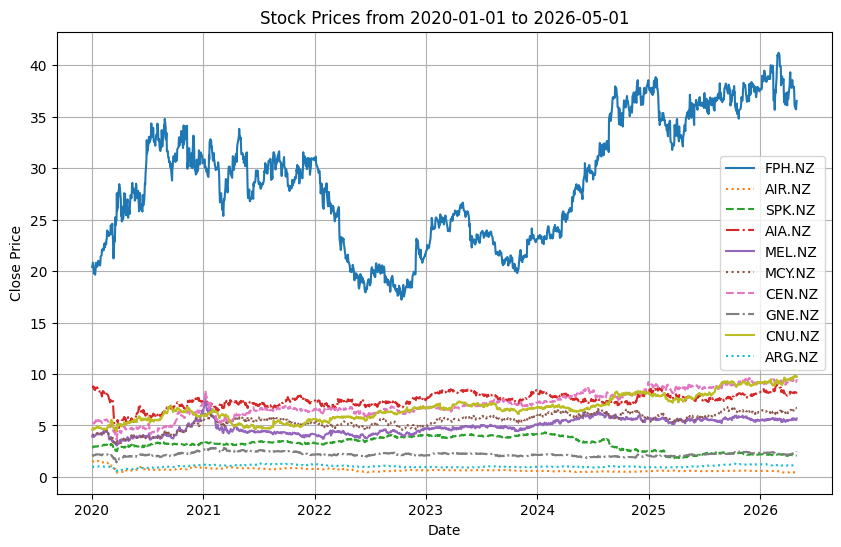

In [4]:
start_date = "2020-01-01"
end_date = "2026-05-01"
plot_stock_prices(nzx_tickers, start_date, end_date)

In [18]:
# Fetch NZX Data
def fetch_nzx_data(tickers):
    rows = []

    for symbol in tickers:
        t = yf.Ticker(symbol)

        info = t.fast_info
        full = t.info  # fallback for dividend
        financials = t.financials

        # market_cap = info.get("market_cap")
        # price = info.get("last_price")
        price = (
            full.get("currentPrice") or
            full.get("regularMarketPrice") or
            full.get("previousClose")
        )
        market_cap = (full.get("marketCap")
                        or info.get("market_cap")
                        or price * info.get("sharesOutstanding", 0)
        )
        dividend_yield = full.get("dividendYield")
        trailing_pe = full.get("trailingPE")
        forward_pe = full.get("forwardPE")
        revenue = financials.loc["Total Revenue"].iloc[0]
        revenues = financials.loc["Total Revenue"]
        latest = revenues.iloc[0]
        previous = revenues.iloc[1]
        growth = (latest - previous) / previous
        shares = t.info.get("sharesOutstanding")
        revenue_per_share = latest / shares if shares else None

        rows.append({
            "Ticker": symbol,
            "MarketCapBillions": market_cap / 1e9,  # Convert to billions
            "Revenue": revenue / 1e9,  # Convert to billions
            "RevenueGrowth": growth,
            "RevenuePerShare": revenue_per_share,
            "Price": price,
            "DividendYield": dividend_yield,
            "TrailingPE": trailing_pe,
            "ForwardPE": forward_pe,
        })

    return pd.DataFrame(rows)

In [19]:
print(fetch_nzx_data(nzx_tickers))

    Ticker  MarketCapBillions    Revenue  RevenueGrowth  RevenuePerShare  \
0   FPH.NZ          20.132268   1.280300      -0.271771         2.180017   
1   FSF.NZ           0.719654   0.067000       0.135593         0.623772   
2   FCG.NZ          10.395155  24.111000       0.180581        10.020007   
3   SEK.NZ           0.227154   0.411412       0.367181         9.309367   
4   LIC.NZ           0.157551        NaN            NaN              NaN   
5   TWR.NZ           0.728032   0.541558       0.097742         1.576995   
6   AIR.NZ           1.406600   6.755000       0.000444         2.089027   
7   SPK.NZ           3.912526   3.623000      -0.036180         1.916820   
8   AIA.NZ          14.222138   0.929300       0.110673         0.548218   
9   MEL.NZ          15.304885   4.794000      -0.007659         1.816753   
10  MCY.NZ           9.780012   3.498000       0.019825         2.467911   
11  CEN.NZ           9.576304   3.412000       0.200986         3.431132   
12  GNE.NZ  

In [ ]:
nvda  = pd.Series(yf.Ticker("NVDA"))
print(nvda)

nvda  = pd.Series(yf.Ticker("NVDA").info)
print(nvda)

0    yfinance.Ticker object <NVDA>
dtype: object
address1                                                     2788 San Tomas Expressway
city                                                                       Santa Clara
state                                                                               CA
zip                                                                              95051
country                                                                  United States
phone                                                                     408 486 2000
website                                                         https://www.nvidia.com
industry                                                                Semiconductors
industryKey                                                             semiconductors
industryDisp                                                            Semiconductors
sector                                                                      Techn

In [5]:
spark  = pd.Series(yf.Ticker("SPK.NZ").info)
print(spark)

address1                                                                    Spark City
address2                                    Level 1 50 Albert Street Private Bag 92028
city                                                                          Auckland
zip                                                                               1010
country                                                                    New Zealand
phone                                                                    64 4 471 1638
website                                                      https://www.sparknz.co.nz
industry                                                              Telecom Services
industryKey                                                           telecom-services
industryDisp                                                          Telecom Services
sector                                                          Communication Services
sectorKey                                  

In [6]:
abbott  = pd.Series(yf.Ticker("ABT").info)
print(abbott)

address1                                                          100 Abbott Park Road
city                                                                       Abbott Park
state                                                                               IL
zip                                                                         60064-6400
country                                                                  United States
phone                                                                     224 667 6100
website                                                         https://www.abbott.com
industry                                                               Medical Devices
industryKey                                                            medical-devices
industryDisp                                                           Medical Devices
sector                                                                      Healthcare
sectorKey                                  

In [3]:
genesis  = pd.Series(yf.Ticker("GNE.NZ").info)


chorus = pd.Series(yf.Ticker("CNU.NZ").info)


argosy = pd.Series(yf.Ticker("ARG.NZ").info)


In [7]:
print(f"{spark.sector=}")
print(f"{abbott.sector=}")
print(f"{genesis.sector=}")
print(f"{chorus.sector=}")
print(f"{argosy.sector=}")

spark.sector='Communication Services'
abbott.sector='Healthcare'
genesis.sector='Utilities'
chorus.sector='Communication Services'
argosy.sector='Real Estate'


Currency : NZD
Currency : USD
Currency : NZD
Currency : NZD


[*********************100%***********************]  5 of 5 completed

Currency : NZD


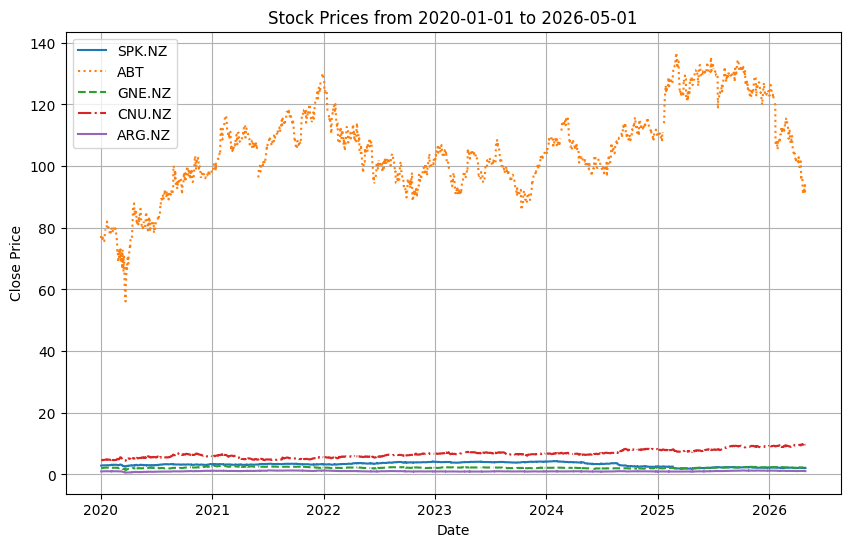

In [ ]:
tickers = ["SPK.NZ", "ABT", "GNE.NZ", "CNU.NZ", "ARG.NZ"]
start_date = "2020-01-01"
end_date = "2026-05-01"
plot_stock_prices(tickers, start_date, end_date)